In [1]:
import sys
import os
import scMPRAforge as scm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

2025-08-30 11:41:26.671873: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-30 11:41:26.676007: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-08-30 11:41:26.676020: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

cluster=SLURMCluster(
    cores=4,#cores per slurm job
    memory="128G",#memory per slurm job
    processes=16,#dask workers
    job_extra_directives=["-p ycga", 
        f"--job-name=simclust_worker",
        f"--time=4:00:00",
        f"--output=slave_%j.out"]
)

cluster.scale(jobs=4)

client = Client(cluster,
        timeout=f"{5*60}s",   # Client <-> scheduler timeout 
        heartbeat_interval="20s"  # Worker heartbeat interval
    )

In [4]:
#load data
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="shendure_ortho_20260306"
primordial=scm.ortho.load(client,path,name)

In [5]:
#create a simulation batch object
batch=scm.simulation_batch(primordial)
batch.describe_primordial()

scMPRAforge: WARNING: Losing params                                    mu        zi     theta
cre_id           cell_type rep_id                        
Lamc1_chr1_12183 reference 2B1    NaN  0.676931  0.065252
                           2B2    NaN  0.942125  0.065252
                           A1     NaN  0.940196  0.065252
                           A2     NaN  0.040005  0.065252
                           B1     NaN  0.216348  0.065252
                           B2     NaN  0.642718  0.065252


In [6]:
batch.description_primordial_by_cell_type

,index,cell_type,cre_id,rep_id,mu,zi,theta,cells,r,sigmasquare,p
npartitions=2,,,,,,,,,,,
0,int64,string,string,string,float64,float64,float32,int64,float32,float64,float64
4375,...,...,...,...,...,...,...,...,...,...,...
8748,...,...,...,...,...,...,...,...,...,...,...


In [8]:
batch.description_primordial_by_cell_type.head(5)

,index,cell_type,cre_id,rep_id,mu,zi,theta,cells,r,sigmasquare,p
0,0,NeuroectodermBrain,Bend5_chr4_8168,2B1,0.021062,0.032881,0.395536,91,0.395536,0.022183,0.949444
1,1,NeuroectodermBrain,Bend5_chr4_8168,2B2,0.021062,0.013529,0.395536,88,0.395536,0.022183,0.949444
2,2,NeuroectodermBrain,Bend5_chr4_8168,A1,0.021062,0.048225,0.395536,79,0.395536,0.022183,0.949444
3,3,NeuroectodermBrain,Bend5_chr4_8168,A2,0.021062,0.028620,0.395536,88,0.395536,0.022183,0.949444
4,4,NeuroectodermBrain,Bend5_chr4_8168,B1,0.021062,0.023703,0.395536,46,0.395536,0.022183,0.949444


In [7]:
batch.description_primordial_by_cre

,index,cre_id,cell_type,rep_id,mu,zi,theta,cells,r,sigmasquare,p
npartitions=2,,,,,,,,,,,
0,int64,string,string,string,float64,float64,float32,int64,float32,float64,float64
4369,...,...,...,...,...,...,...,...,...,...,...
8736,...,...,...,...,...,...,...,...,...,...,...


In [6]:
batch.simulate_many(client,3)

In [7]:
batch.fit_to_simulations(client)

In [8]:
batch._flatten_all_parameters()

Lame manual save/load (replace later with a function)...

In [13]:
!mkdir -p /gpfs/gibbs/pi/reilly/tabula_data/simulated/shendure_triple_simbatch/simulated_from_cre
!mkdir -p /gpfs/gibbs/pi/reilly/tabula_data/simulated/shendure_triple_simbatch/simulated_from_cell_type

In [ ]:
data_root="/gpfs/gibbs/pi/reilly/tabula_data/simulated/shendure_triple_simbatch"

In [ ]:
for i in batch.simulated_from_cre:
    pass

In [ ]:
batch.ortho_simulated_cre
batch.ortho_simulated_cell_type

Comparing every rep to every primordial:

In [ ]:
simu_batch_type="cre_id"
simu_batch_replicate=0


batch_of_interest

In [53]:
ret=[]

#gt is "ground truth"
#it's not useful to compare 
for simu_rep in [0,1,2]:
    for gt,gt_type in ((batch.description_primordial_by_cre.compute(),"by_cre"),(batch.description_primordial_by_cell_type.compute(),"by_cell_type")):
        
        gt=gt[["cre_id","cell_type","rep_id","mu"]]
        gt=gt.rename({"mu":"true_mu"},axis=1)

        if gt_type=="by_cre":
            batch_of_interest=batch.ortho_simulated_cre[simu_rep]
        else:
            batch_of_interest=batch.ortho_simulated_cell_type[simu_rep]
        
        for replicate in gt["rep_id"].unique():
            gt_replicate_of_interest=gt[gt["rep_id"]==replicate].drop(columns=["rep_id"])
            gt_replicate_of_interest=gt_replicate_of_interest.set_index(["cre_id","cell_type"])
            working=scm.versus_truth(ground_truth_mu=gt_replicate_of_interest,inp_ortho=batch_of_interest)
            working["gt_type"]=gt_type
            working["simu_batch_replicate"]=simu_batch_replicate
            ret.append(working)
        
    



scMPRAforge: WARNING: Losing params                                              mu        zi    theta
cre_id            cell_type          rep_id                       
Txndc12_chr4_7969 ExEndodermVisceral 2B1    NaN  0.278981  0.22166
                                     2B2    NaN  0.114629  0.22166
                                     A1     NaN  0.989311  0.22166
                                     A2     NaN  0.960255  0.22166
                                     B1     NaN  0.604583  0.22166
                                     B2     NaN  0.114383  0.22166
scMPRAforge: WARNING: Losing params                                              mu        zi    theta
cre_id            cell_type          rep_id                       
Txndc12_chr4_7969 ExEndodermVisceral 2B1    NaN  0.278981  0.22166
                                     2B2    NaN  0.114629  0.22166
                                     A1     NaN  0.989311  0.22166
                                     A2     NaN  0.960255

In [56]:
summary=pd.concat(ret)

In [59]:
summary.to_csv("shendure_simulated_replicates_summary.tsv",sep="\t")

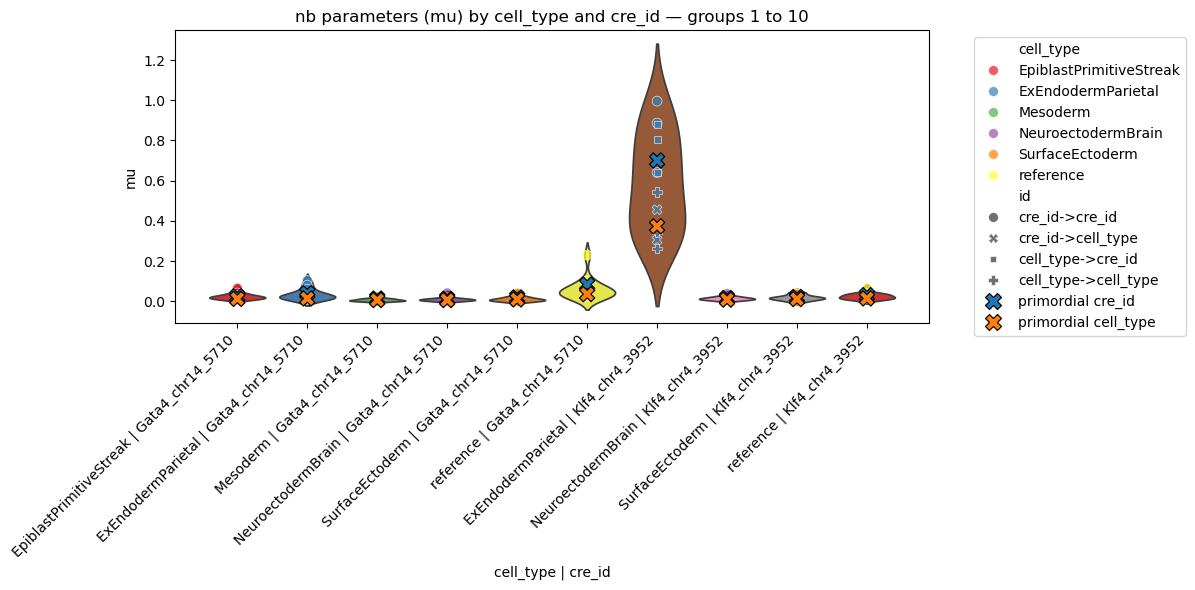

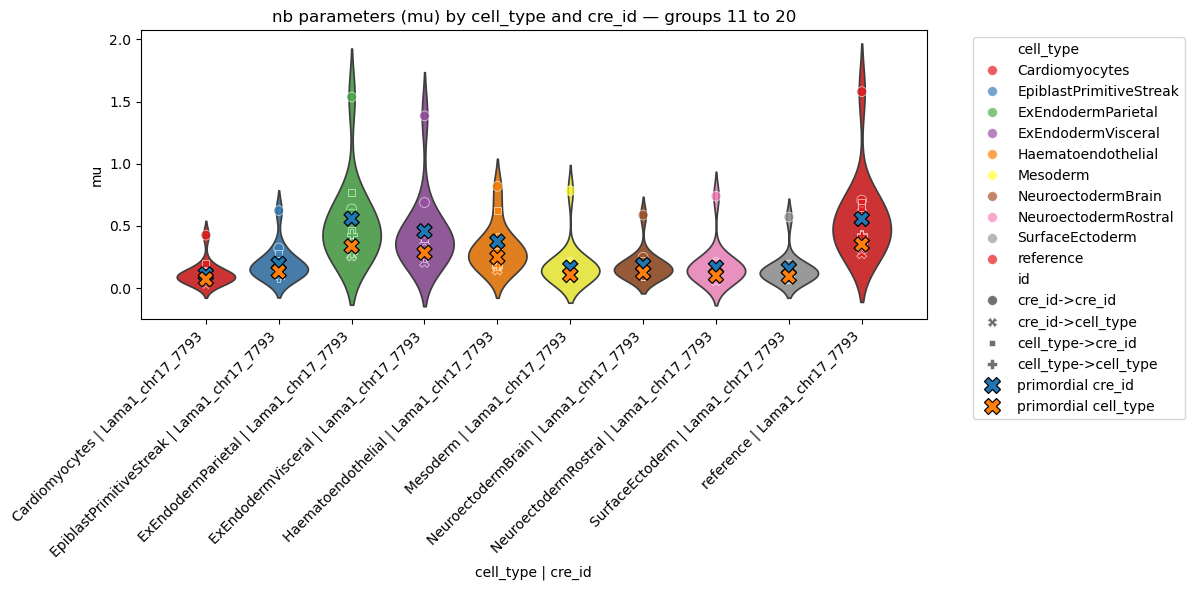

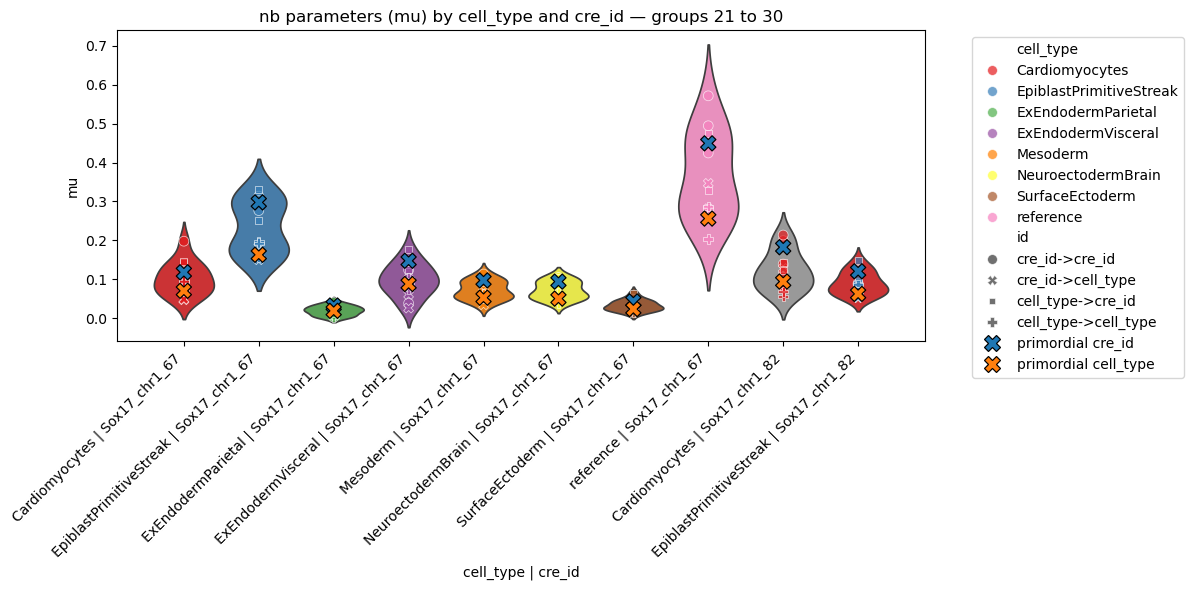

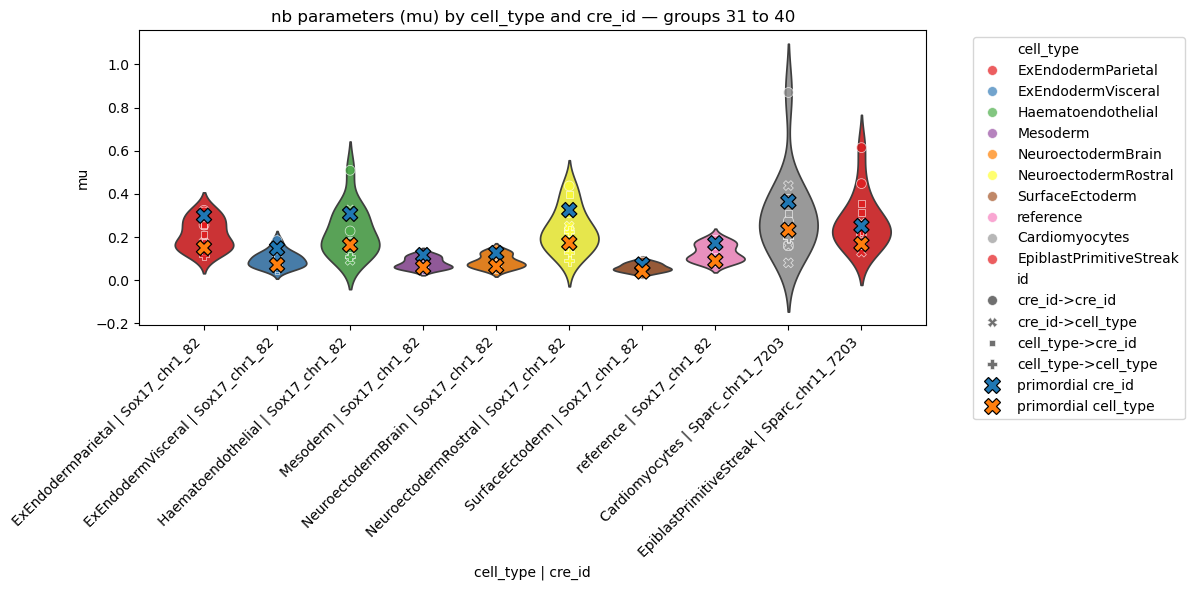

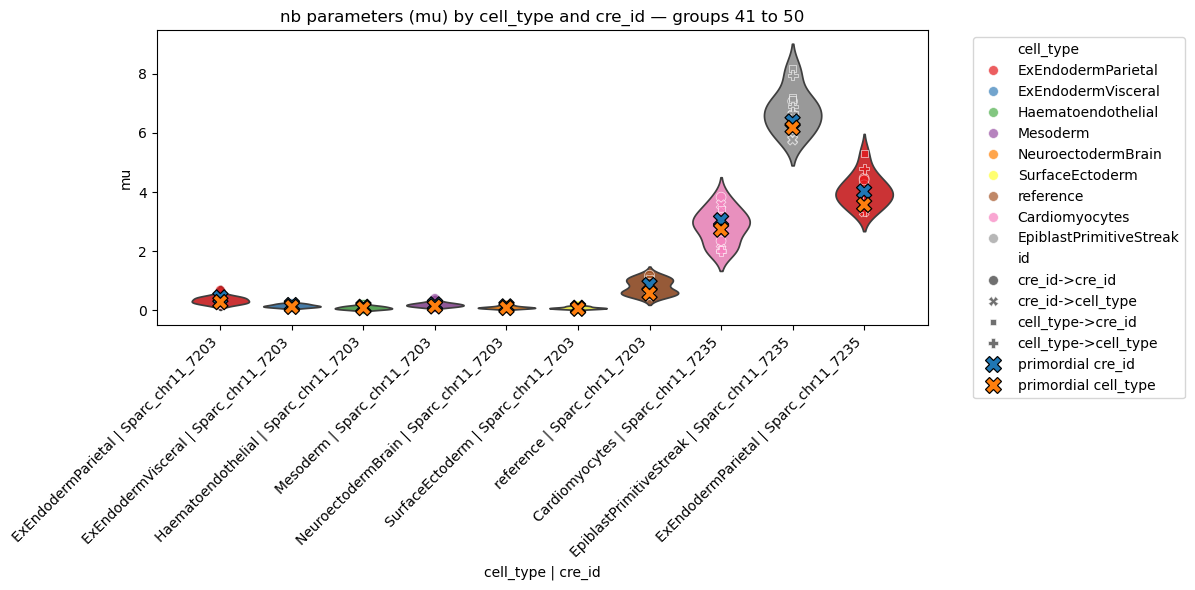

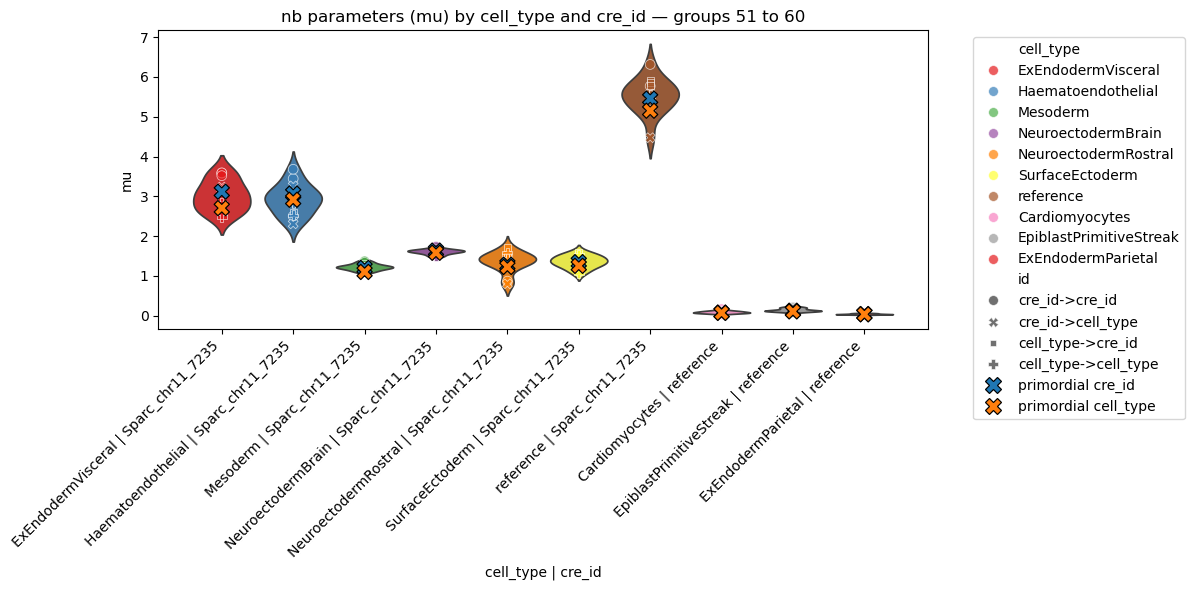

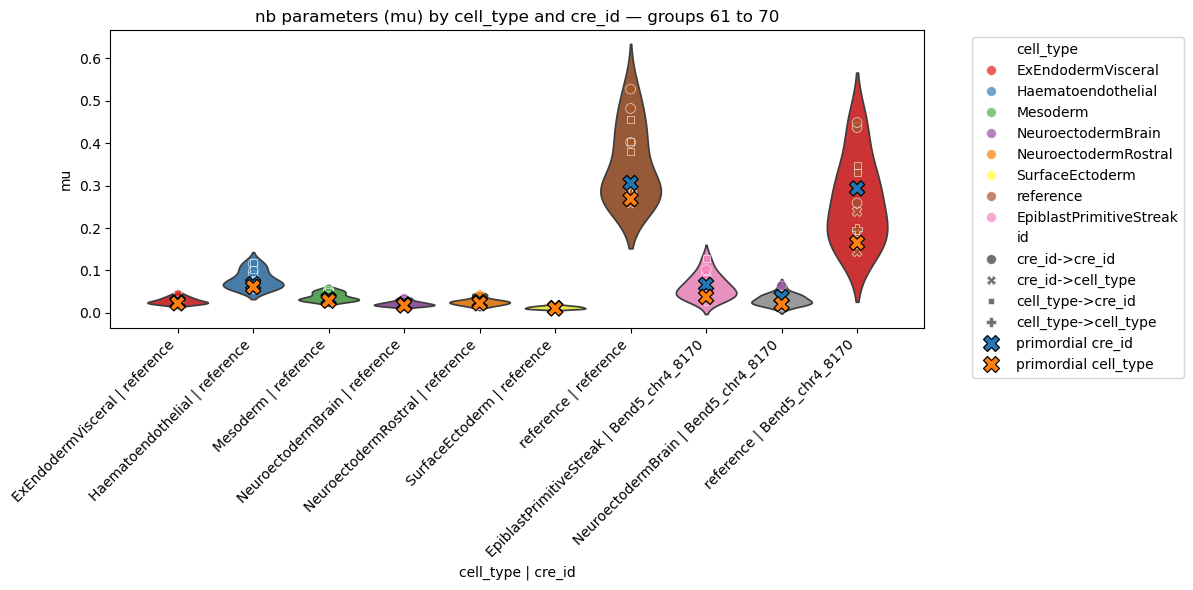

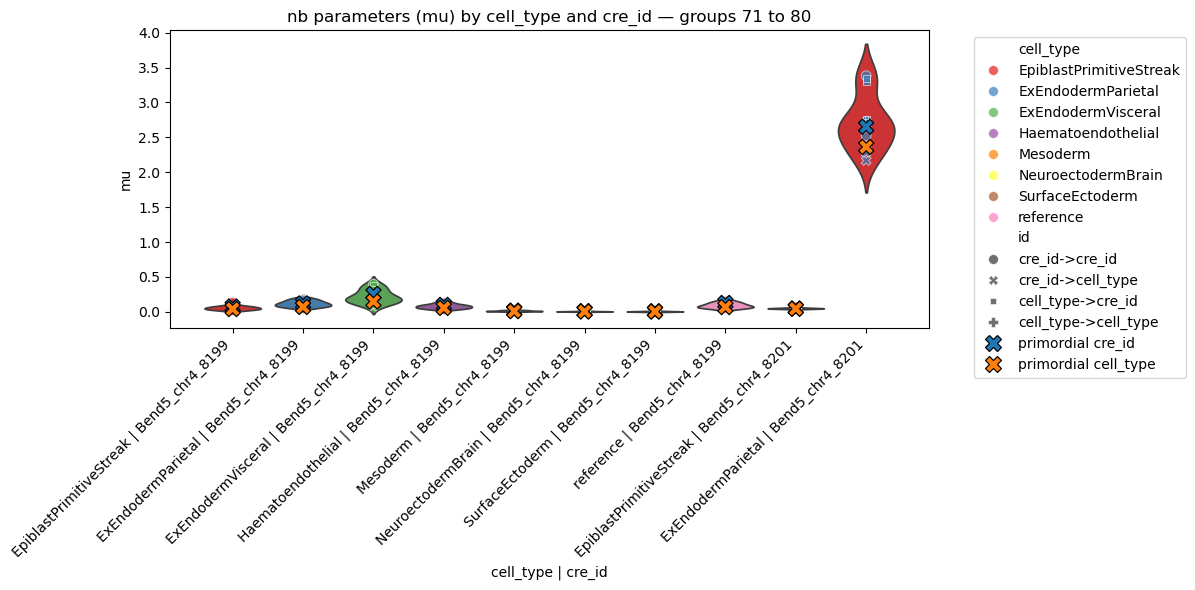

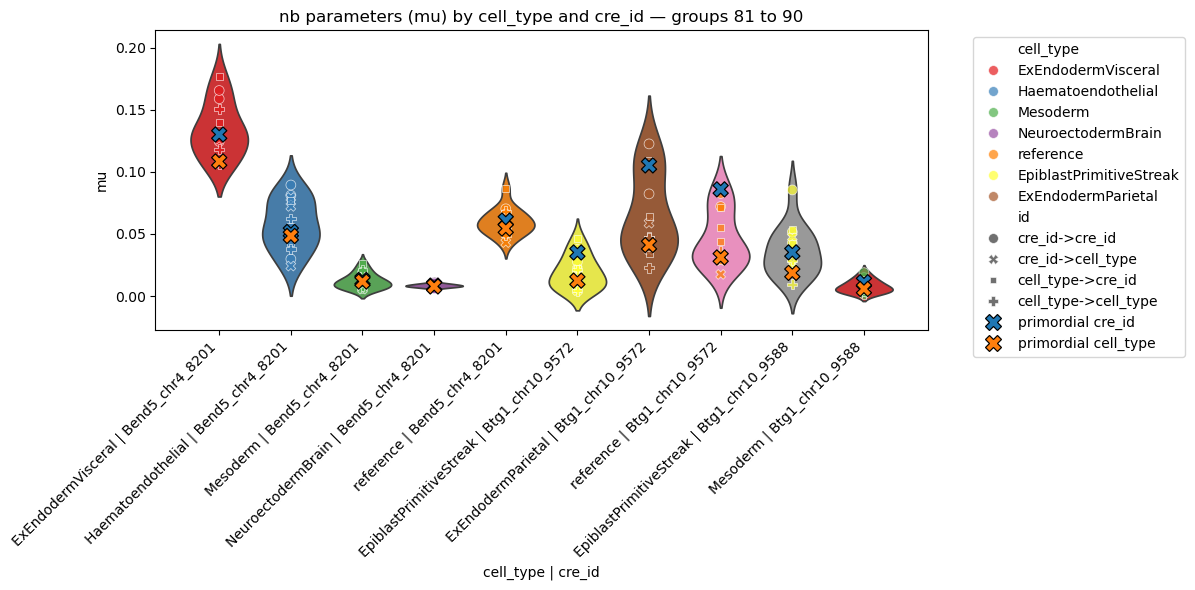

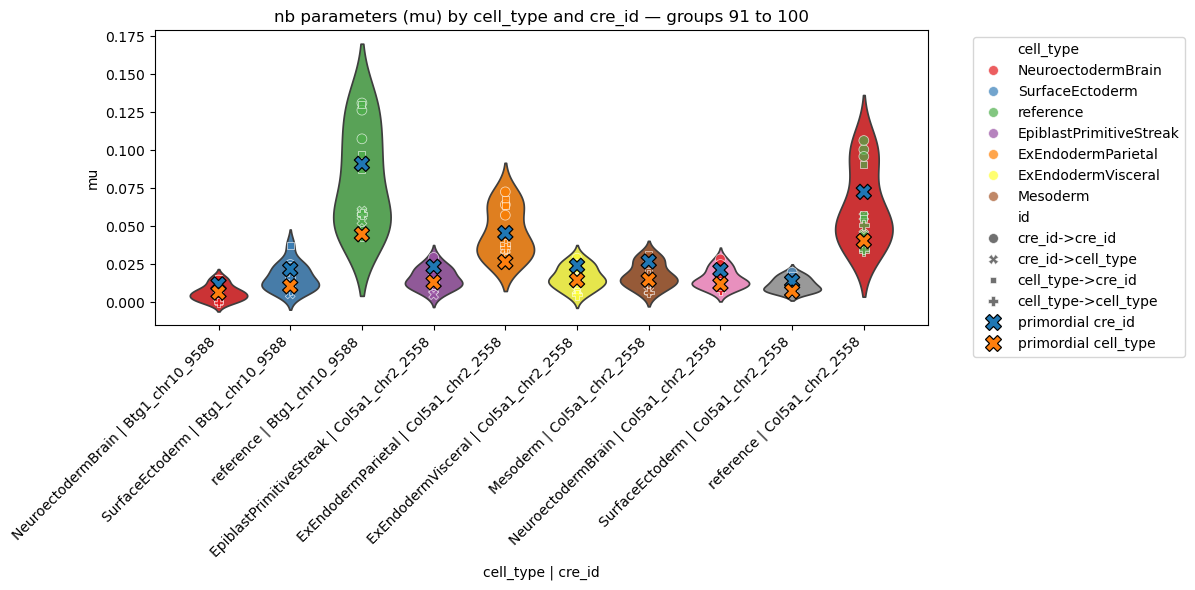

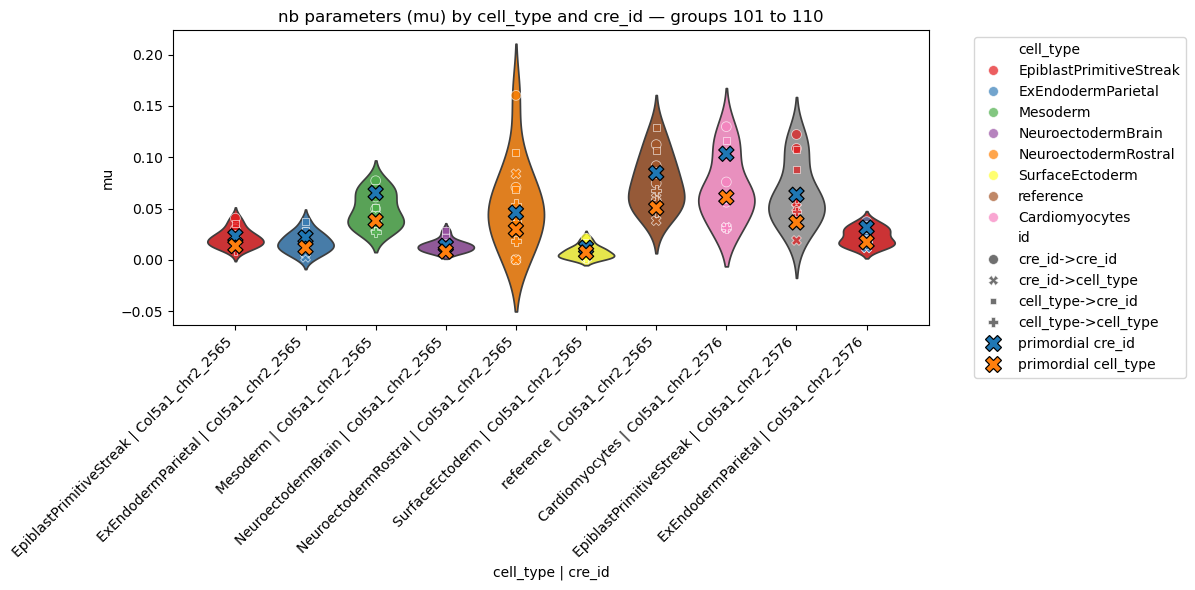

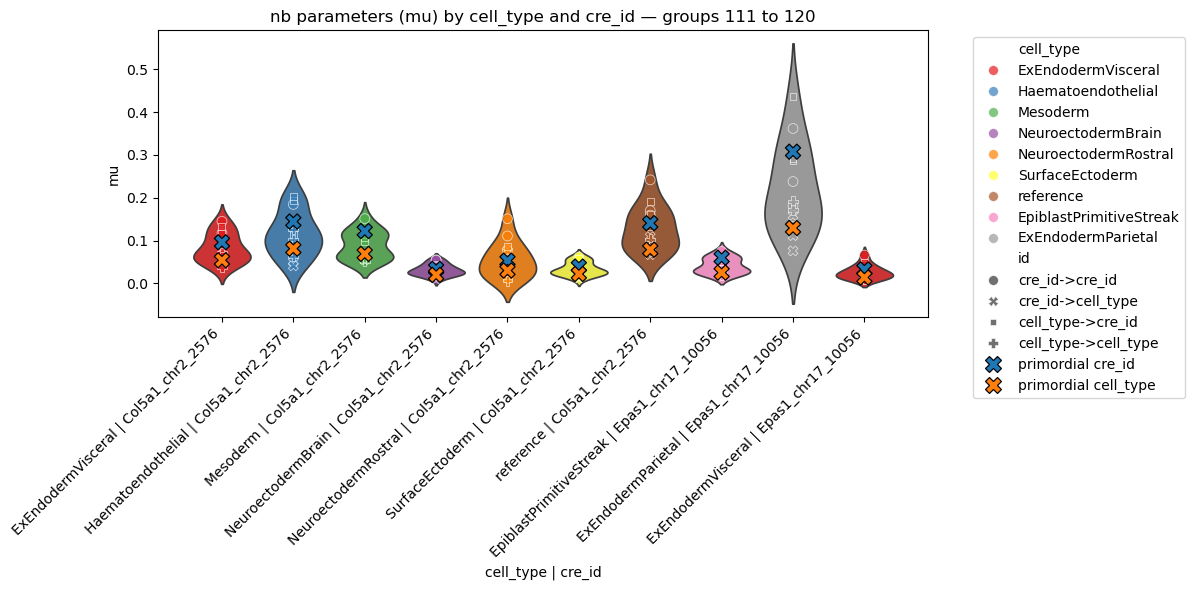

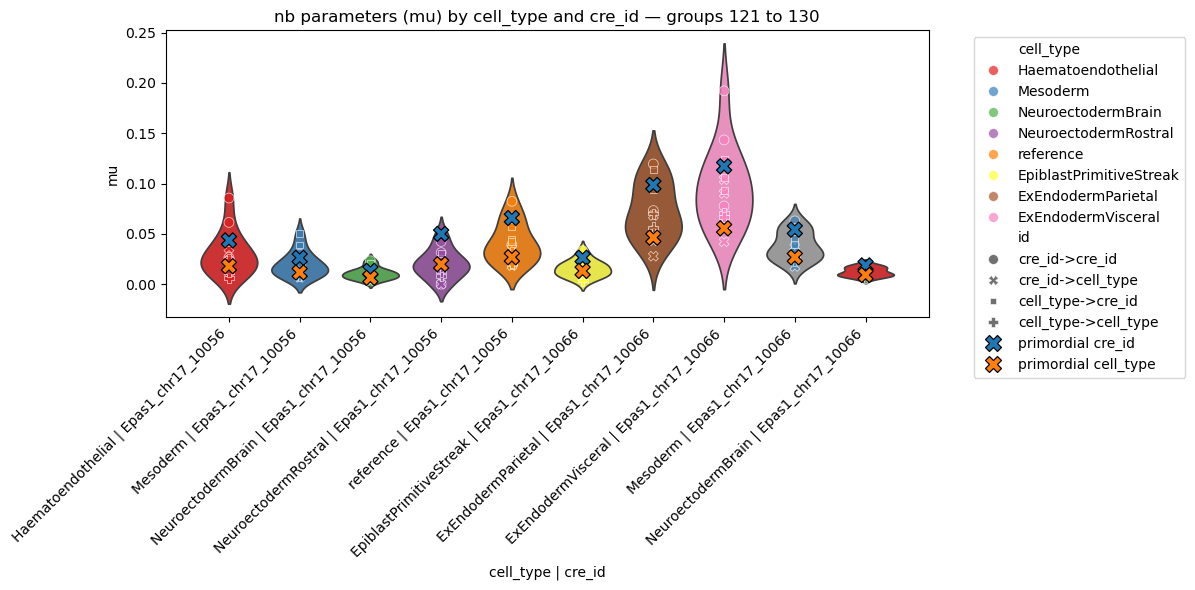

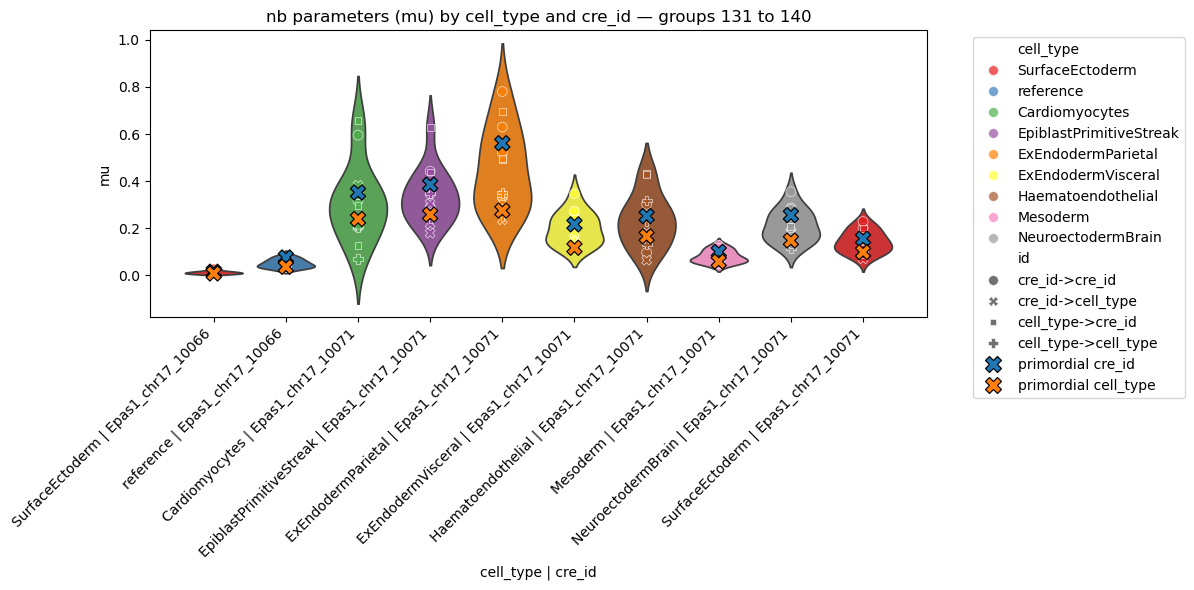

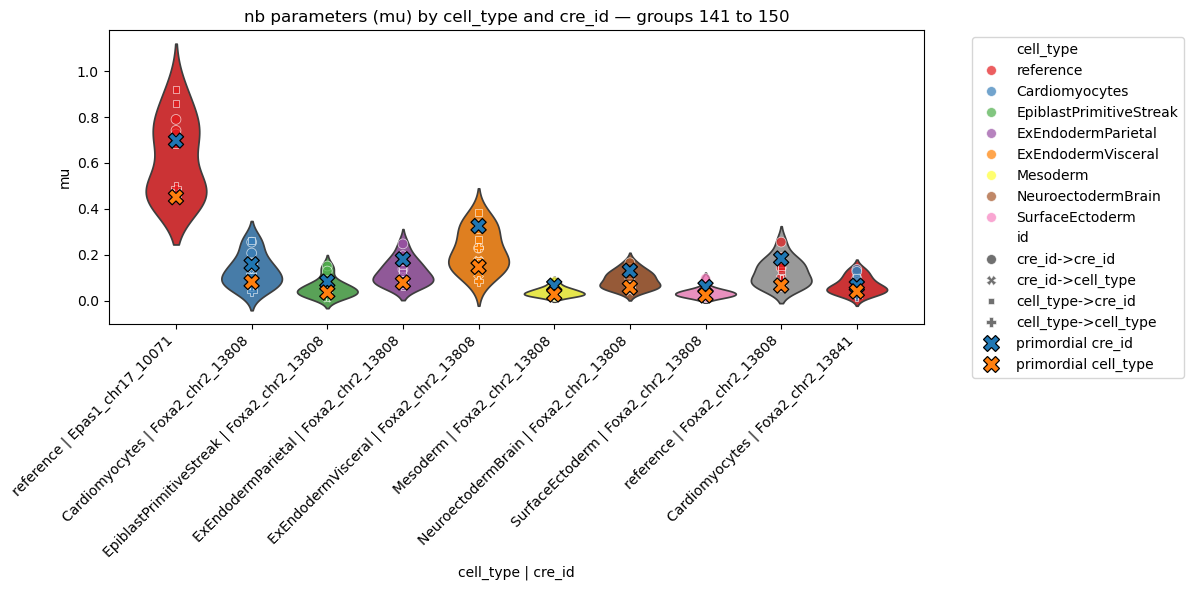

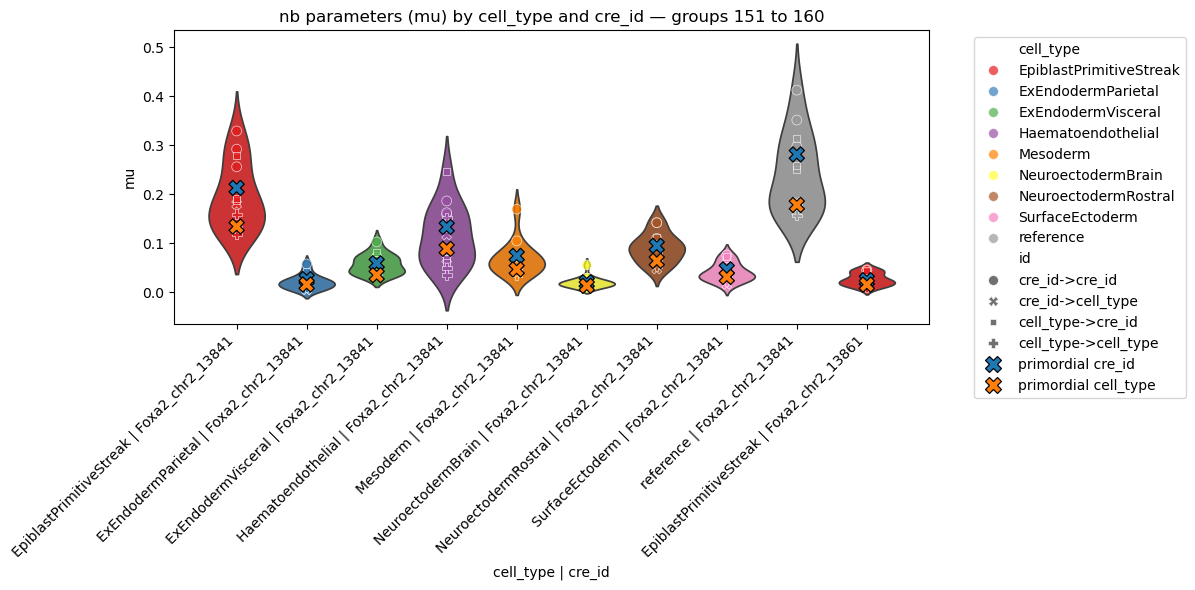

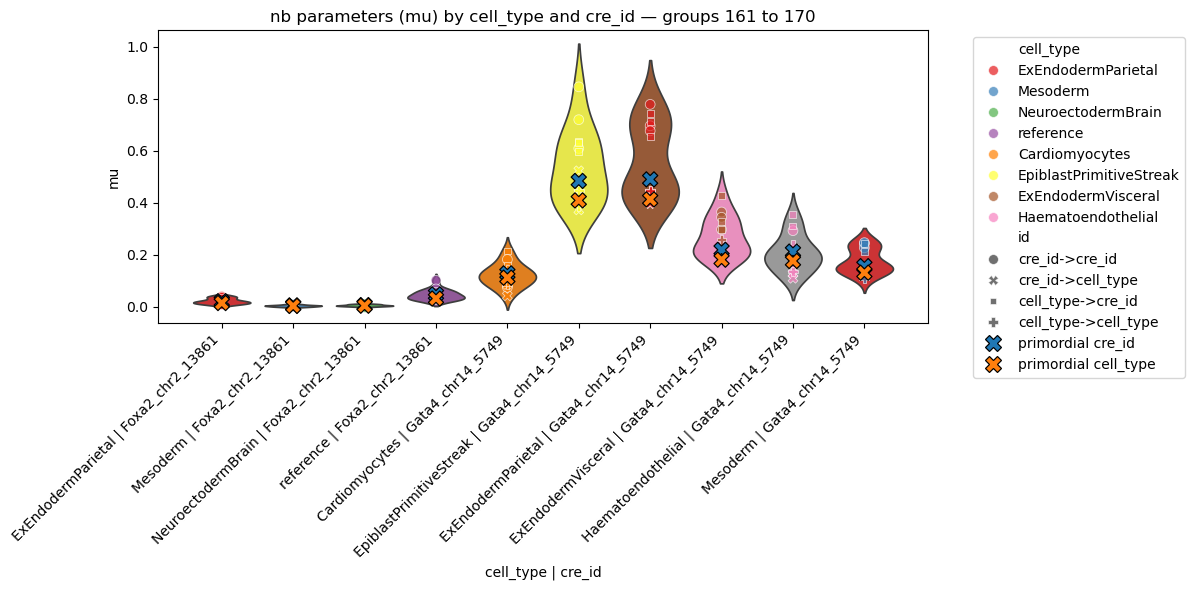

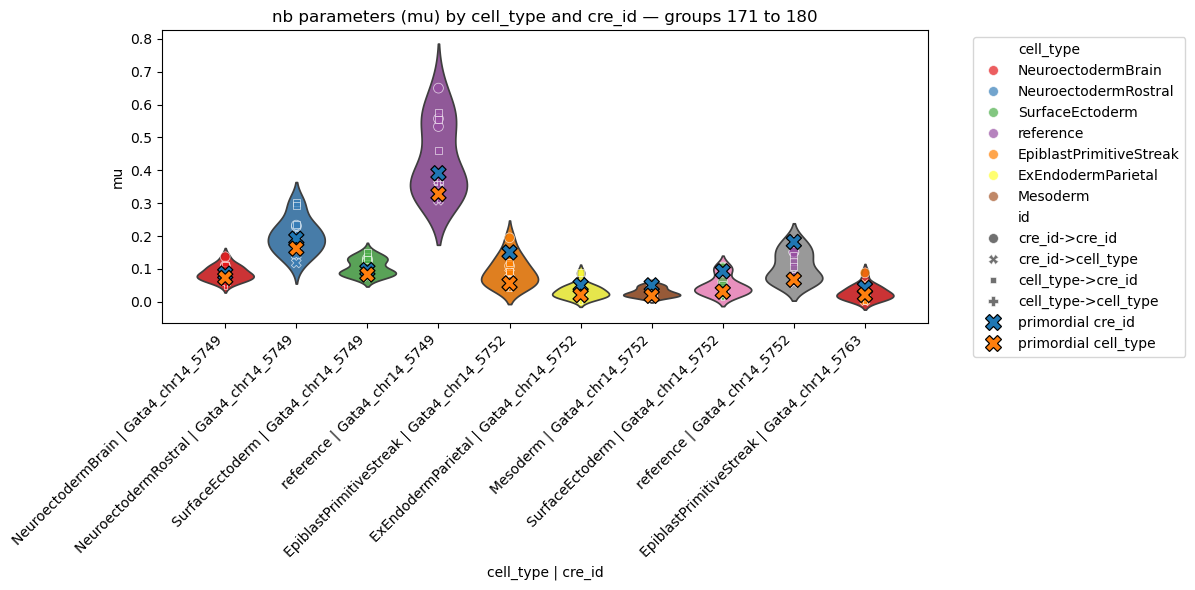

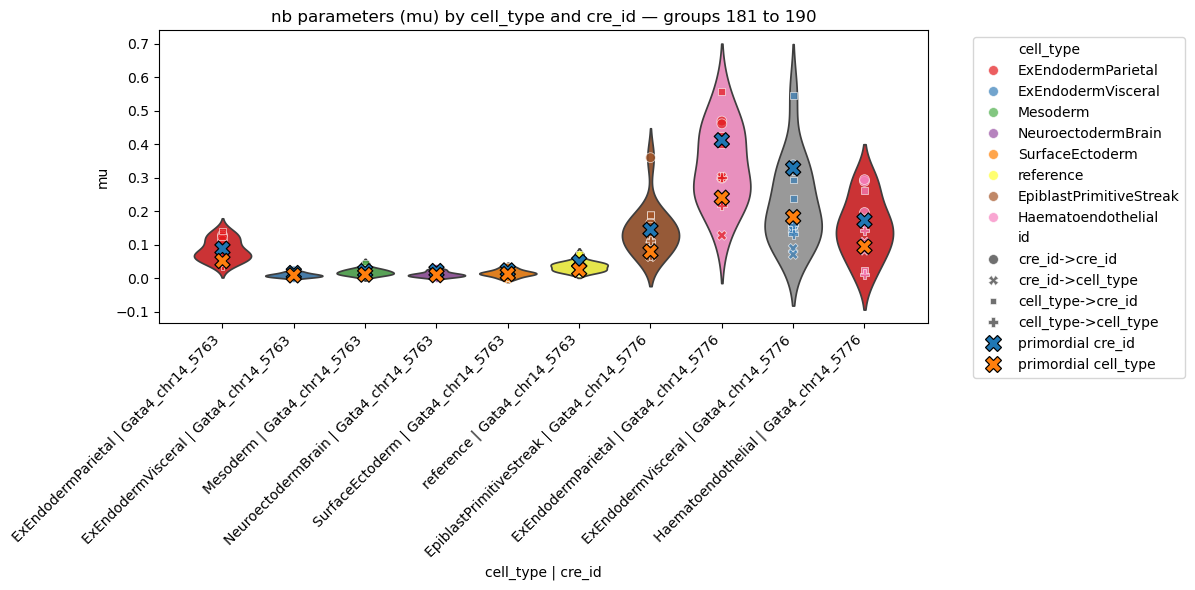

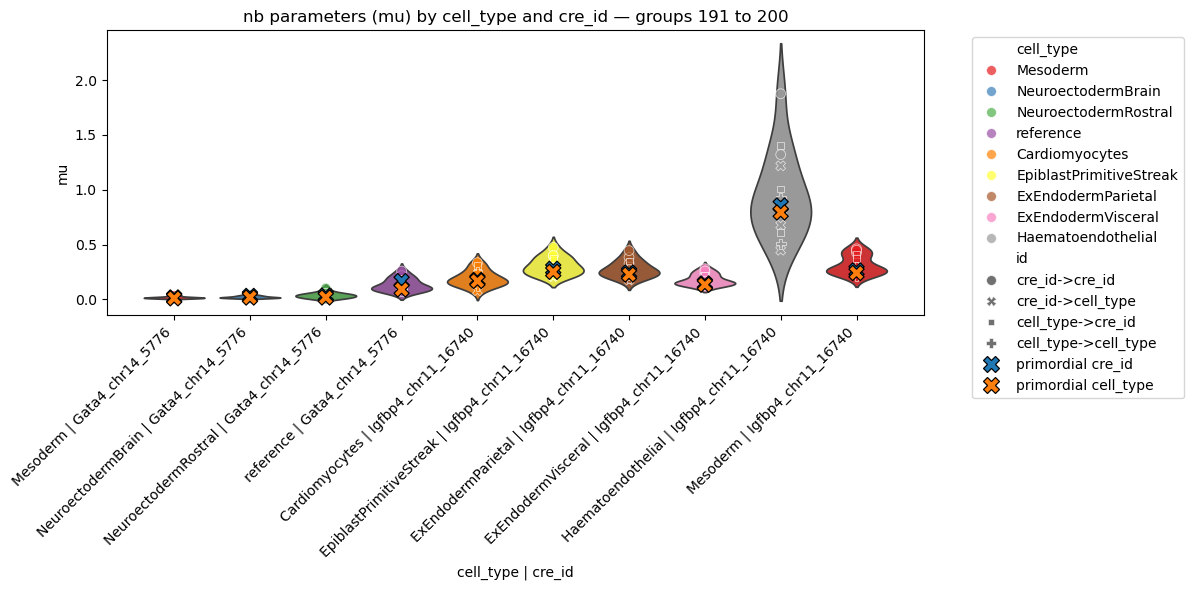

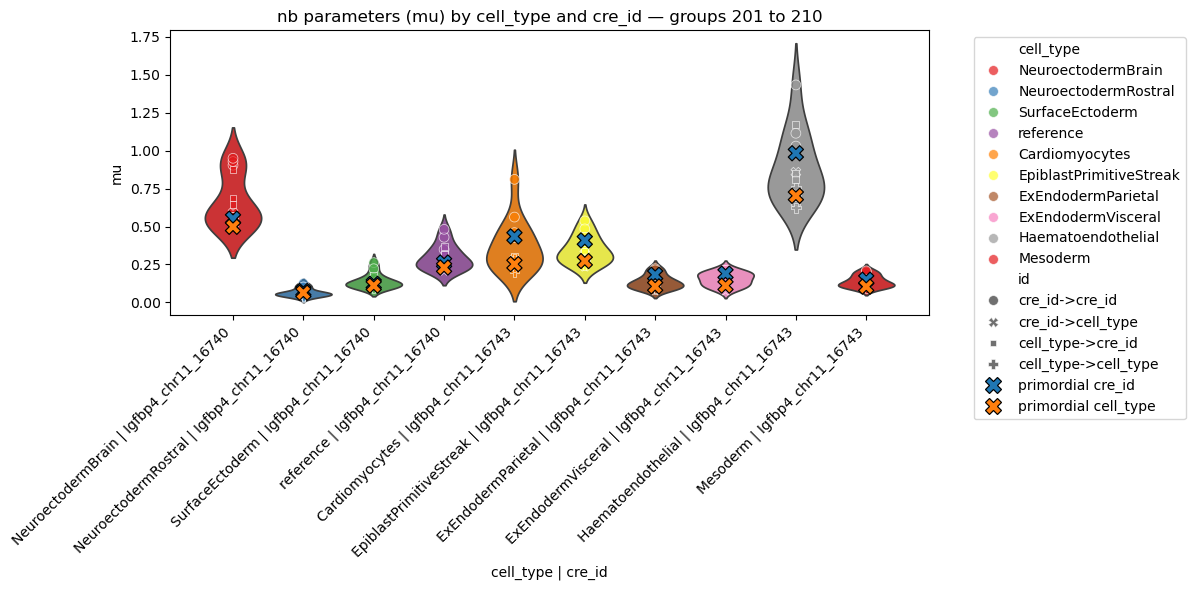

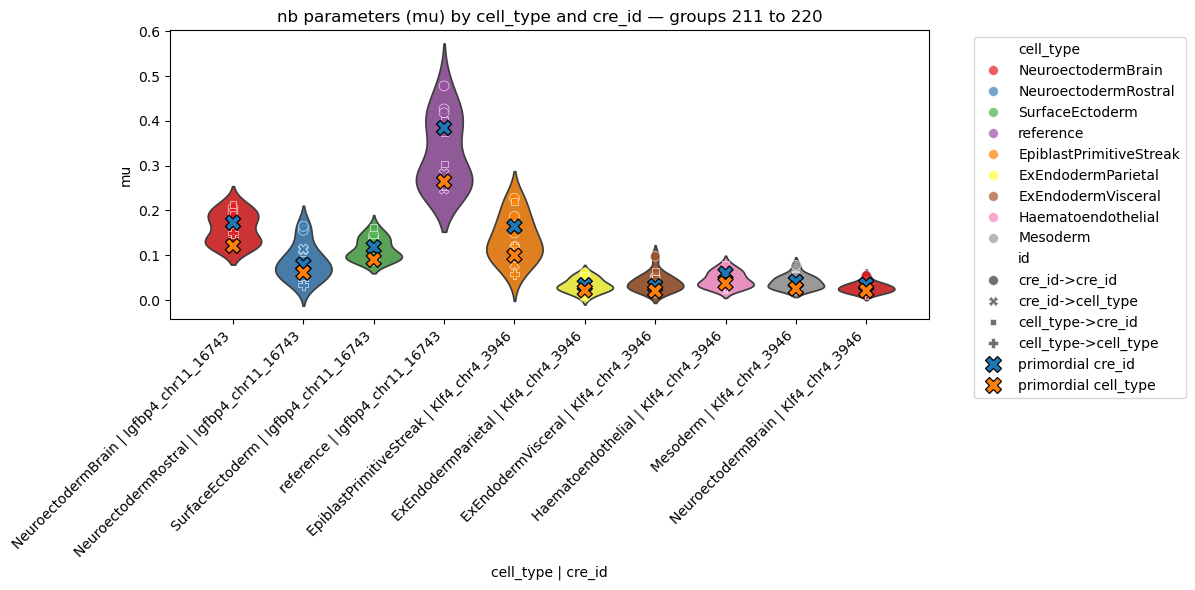

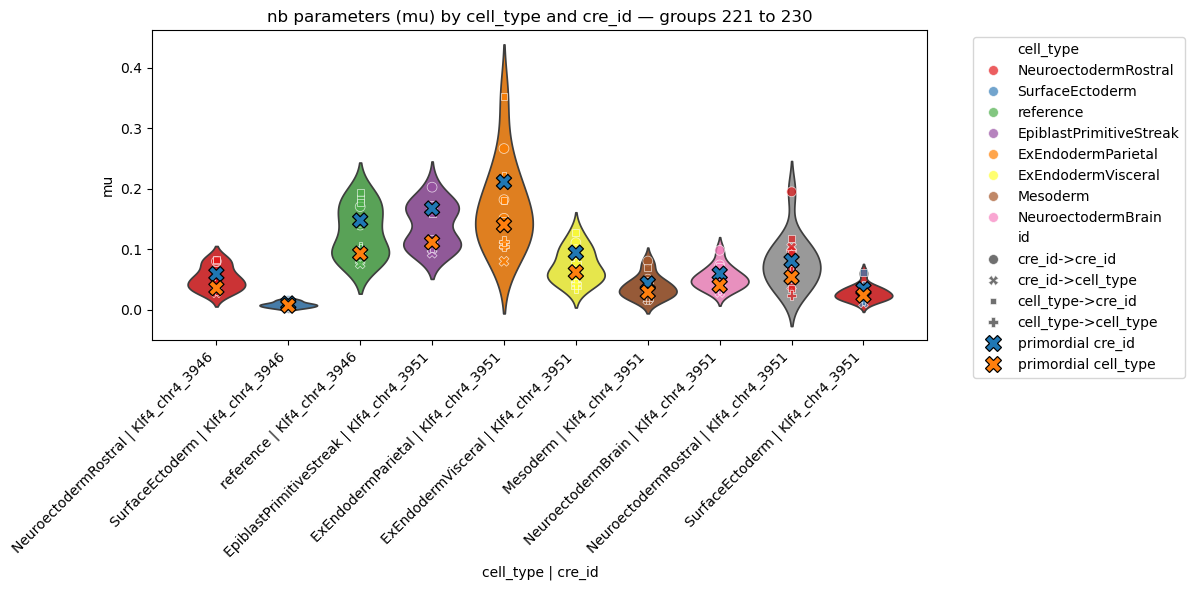

KeyboardInterrupt: 

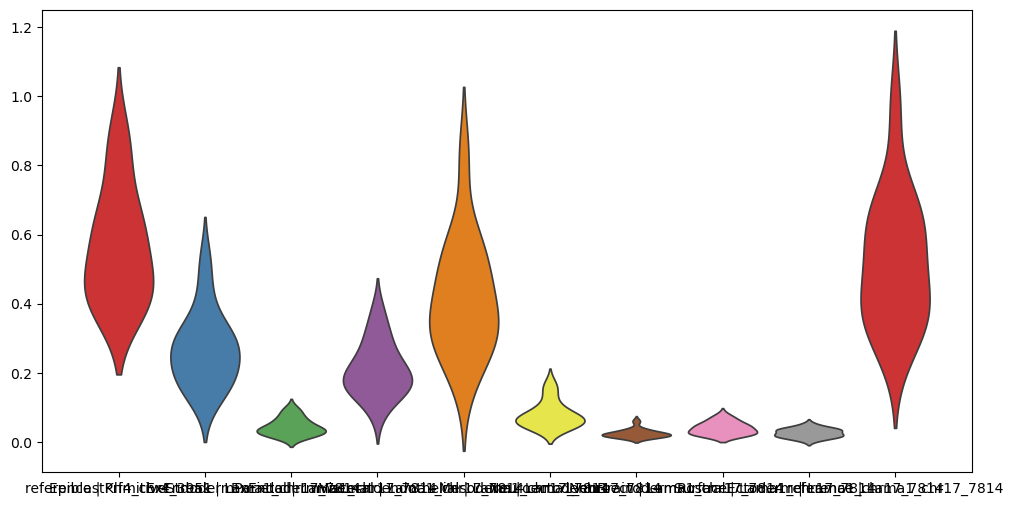

In [60]:
batch.plot_nb_spread(groups_per_plot=10)

In [9]:
cluster.close()